# Multimodelni sistem za detekciju pada
## SisFall Dataset | Računarska inteligencija

**Stefan Ilić SV12/2023**

---

### Pregled projekta

Ovaj notebook implementira i evaluira sistem za **automatsku detekciju pada** zasnovan na podacima akcelerometra i žiroskopa pričvršćenih za pojas osobe.

**Dataset:** [SisFall](https://www.kaggle.com/datasets/nvnikhil0001/sis-fall-original-dataset) — 38 subjekata (23 mlada + 15 starijih), 200 Hz, 9-osni senzori (2 akcelerometra + 1 žiroskop), 19 vrsta ADL + 15 vrsta padova.

**Pipeline:**
1. Učitavanje podataka + ADC → g konverzija  
2. Exploratory Data Analysis (EDA)  
3. Sliding Window segmentacija + Feature Engineering  
4. Grupna podela po subjektima (GroupKFold — sprečava Data Leakage)  
5. Treniranje 3 modela: Gaussian Naive Bayes, kNN, MLP  
6. Komparativna evaluacija + ROC krive  

---
## 0. Instalacija zavisnosti


In [1]:
import subprocess, sys

required = ["numpy", "pandas", "matplotlib", "seaborn",
            "scikit-learn", "tensorflow", "scipy"]

for pkg in required:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip",
                               "install", pkg, "-q"])
        
print("✓ Sve zavisnosti su dostupne.")


✓ Sve zavisnosti su dostupne.


---
## 1. Učitavanje podataka i konfiguracija

### Šta se radi?
Importujemo module projekta i učitavamo SisFall dataset. Modul `data_loader` automatski:
- rekurzivno pronalazi sve `.txt` fajlove u zadatom folderu,
- parsira ime fajla da odredi subject ID i tip aktivnosti (ADL/Fall),
- detektuje separator (`;` ili `,`) i učitava 9 kolona signala,
- konvertuje ADXL345 iz ADC sirovih vrednosti u **g jedinice** (faktor = 0.00390625).


In [2]:
import os, warnings
warnings.filterwarnings('ignore')

from data_loader import (
    FS, WINDOW_SEC, WINDOW_SAMPLES, STEP_SAMPLES, OVERLAP_PCT,
    FALL_IMPACT_THRESHOLD_G, ADXL345_SCALE,
    load_dataset, plot_eda
)
from features   import apply_sliding_window, split_by_subjects, plot_feature_distributions
from models     import train_gnb, train_knn, train_mlp
from evaluation import plot_model_results, plot_roc_curves, print_final_report

# ─── KONFIGURACIJA ────────────────────────────────────────────────
DATA_PATH  = '..\\SisFall_dataset' 
OUTPUT_DIR = './results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── UČITAVANJE ───────────────────────────────────────────────────
print("=" * 60)
print("  UČITAVANJE SISFALL DATASETA")
print("=" * 60)
records, label_counts = load_dataset(DATA_PATH)


  UČITAVANJE SISFALL DATASETA
  Found 4506 .txt files in: ..\SisFall_dataset
  ✓ Loaded files:  4505  (ADL: 2707, Fall: 1798)
  ✓ Subjects (38): ['SA01', 'SA02', 'SA03', 'SA04', 'SA05', 'SA06', 'SA07', 'SA08', 'SA09', 'SA10', 'SA11', 'SA12', 'SA13', 'SA14', 'SA15', 'SA16', 'SA17', 'SA18', 'SA19', 'SA20', 'SA21', 'SA22', 'SA23', 'SE01', 'SE02', 'SE03', 'SE04', 'SE05', 'SE06', 'SE07', 'SE08', 'SE09', 'SE10', 'SE11', 'SE12', 'SE13', 'SE14', 'SE15']


---
## 2. Exploratory Data Analysis (EDA)

### Šta se radi?
Vizuelizujemo sirove signale i distribucije da razumemo razlike između ADL i Fall klasa pre nego što počnemo sa mašinskim učenjem.

### Šta tražimo?
- **XYZ ose:** Fall signali imaju kratak impaktni spike (udarac pri dnu pada) vidljiv kao nagla promena amplitude.
- **Vector Magnitude (VM = √(x²+y²+z²)):** Tokom normalnog hodanja VM osciluje oko 1g. Tokom pada, VM prolazi kroz fazu slobodnog pada (<1g) pa impakta (3–8g), što je vizuelno prepoznatljivo.
- **Distribucija klasa:** Proveravamo class imbalance — SisFall ima više ADL fajlova od Fall fajlova.



  VM statistike (20 uzoraka):
    ADL  — mean=1.067g  max=4.010g  std=0.299g
    FALL_IMPACT_THRESHOLD_G = 2.0 g (vm_max iznad praga → label=1 za prozore u Fall fajlovima)
  ✓ EDA grafik sačuvan: ./results\1_eda.png

  Peak VM u Fall primeru: 13.80 g
  Threshold za weak label korekciju: 2.0 g


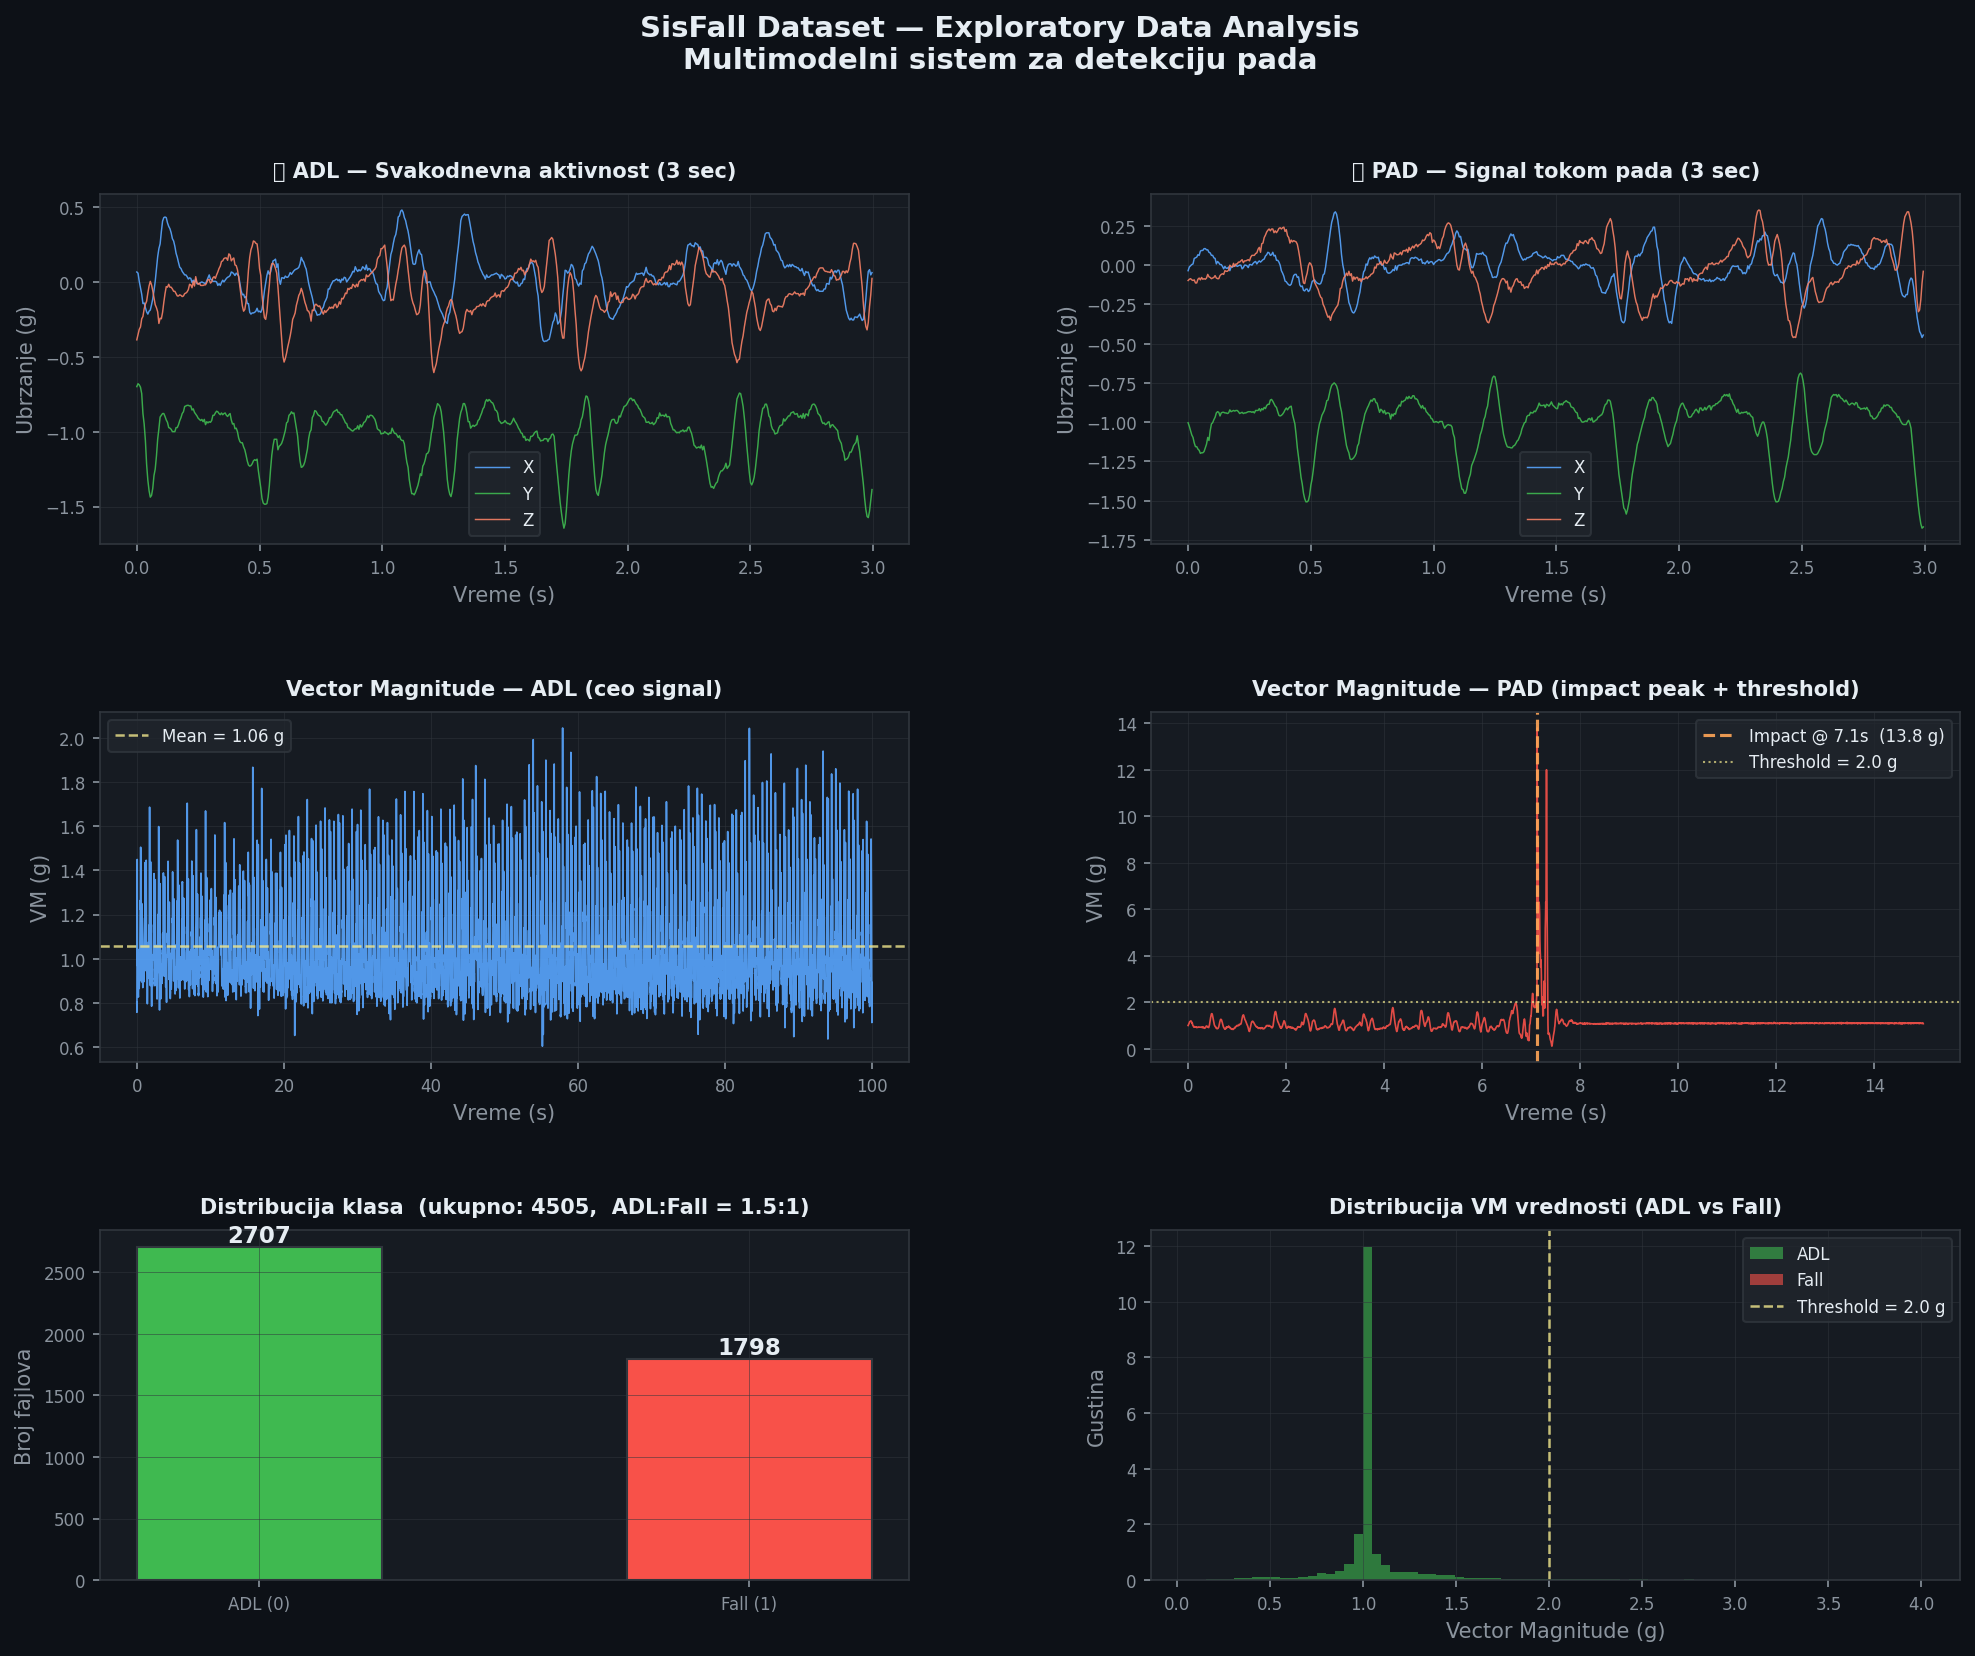

In [3]:
from IPython.display import Image, display

vm_peak = plot_eda(records, label_counts, OUTPUT_DIR, n_vm_samples=20)
print(f"\n  Peak VM u Fall primeru: {vm_peak:.2f} g")
print(f"  Threshold za weak label korekciju: {FALL_IMPACT_THRESHOLD_G} g")

display(Image(os.path.join(OUTPUT_DIR, '1_eda.png'), width=900))


> **Ključna observacija (Weak Labelling problem):**  
> Na grafiku VM Fall signala možemo videti da udarac traje svega ~0.2–0.5 sekunde, dok ostatak fajla (hodanje pre pada + ležanje posle) ima VM sličnu ADL aktivnostima.


---
## 3. Segmentacija signala i Feature Engineering

### Sliding Window segmentacija
Signal se deli na preklapajuće prozore fiksne dužine:
- **Dužina prozora:** 3 sekunde = **600 uzoraka** @ 200 Hz  
  *Zašto 3s?* Dovoljno dugo da uhvati kompletnu fazu pada (pre-impact + impact + post-impact), a dovoljno kratko za real-time latenciju ≤ 1.5s (50% overlap).
- **Preklapanje:** 50% → korak = 300 uzoraka (~1.5s)

### Weak Labelling
Za svaki prozor u **Fall fajlu**:
- `vm_max ≥ 2.0g` → label = **1 (PAD)**  
- `vm_max < 2.0g` → label = **0 (ADL)** — hodanje/stajanje pre/posle udarca

Za svaki prozor u **ADL fajlu**: uvek label = **0 (ADL)**

### 17 obeležja po prozoru
Grupišu se u 4 kategorije: VM statistike, per-osa statistike, žiroskop VM, složena obeležja (SMA, tilt_post).


In [4]:
import numpy as np

print("=" * 60)
print("  SLIDING WINDOW + FEATURE EXTRACTION")
print("=" * 60)
print(f"  Prozor: {WINDOW_SEC}s = {WINDOW_SAMPLES} uzoraka | "
      f"Overlap: {int(OVERLAP_PCT*100)}% | Korak: {STEP_SAMPLES} uzoraka")

X, y, groups, win_stats = apply_sliding_window(records)

print(f"\n  Matrica obeležja X: {X.shape}")
print(f"  Vektor labela    y: {y.shape}  "
      f"(ADL={np.sum(y==0)}, Fall={np.sum(y==1)})")
print(f"\n  Obeležja:")
for i, col in enumerate(X.columns, 1):
    print(f"    {i:2d}. {col}")


  SLIDING WINDOW + FEATURE EXTRACTION
  Prozor: 3.0s = 600 uzoraka | Overlap: 50% | Korak: 300 uzoraka

  Parametri segmentacije:
    FS=200Hz  |  Prozor=3.0s=600 uzoraka  |  Overlap=50%  |  Korak=300 uzoraka
    Weak Labelling threshold: vm_max ≥ 2.0g → label=1

  Statistike prozora po tipu:
    ADL (iz ADL fajla)                    : 31623  (66.3%)
    ADL (mirovanje u Fall fajlu)          : 11725  (24.6%)
    Fall (udarac detektovan)              :  4335  (9.1%)

  UKUPNO prozora: 47683  (ADL=43348, Fall=4335)
  Obeležja: 17  →  ['vm_mean', 'vm_max', 'vm_std', 'vm_range', 'vm_energy', 'vm_zcr', 'ax_std', 'ay_std', 'az_std', 'ax_max', 'ay_max', 'az_max', 'gyro_vm_mean', 'gyro_vm_max', 'gyro_vm_std', 'sma', 'tilt_post']

  Matrica obeležja X: (47683, 17)
  Vektor labela    y: (47683,)  (ADL=43348, Fall=4335)

  Obeležja:
     1. vm_mean
     2. vm_max
     3. vm_std
     4. vm_range
     5. vm_energy
     6. vm_zcr
     7. ax_std
     8. ay_std
     9. az_std
    10. ax_max
    11. ay

  ✓ Feature distribucije sačuvane: ./results\2_feature_distributions.png


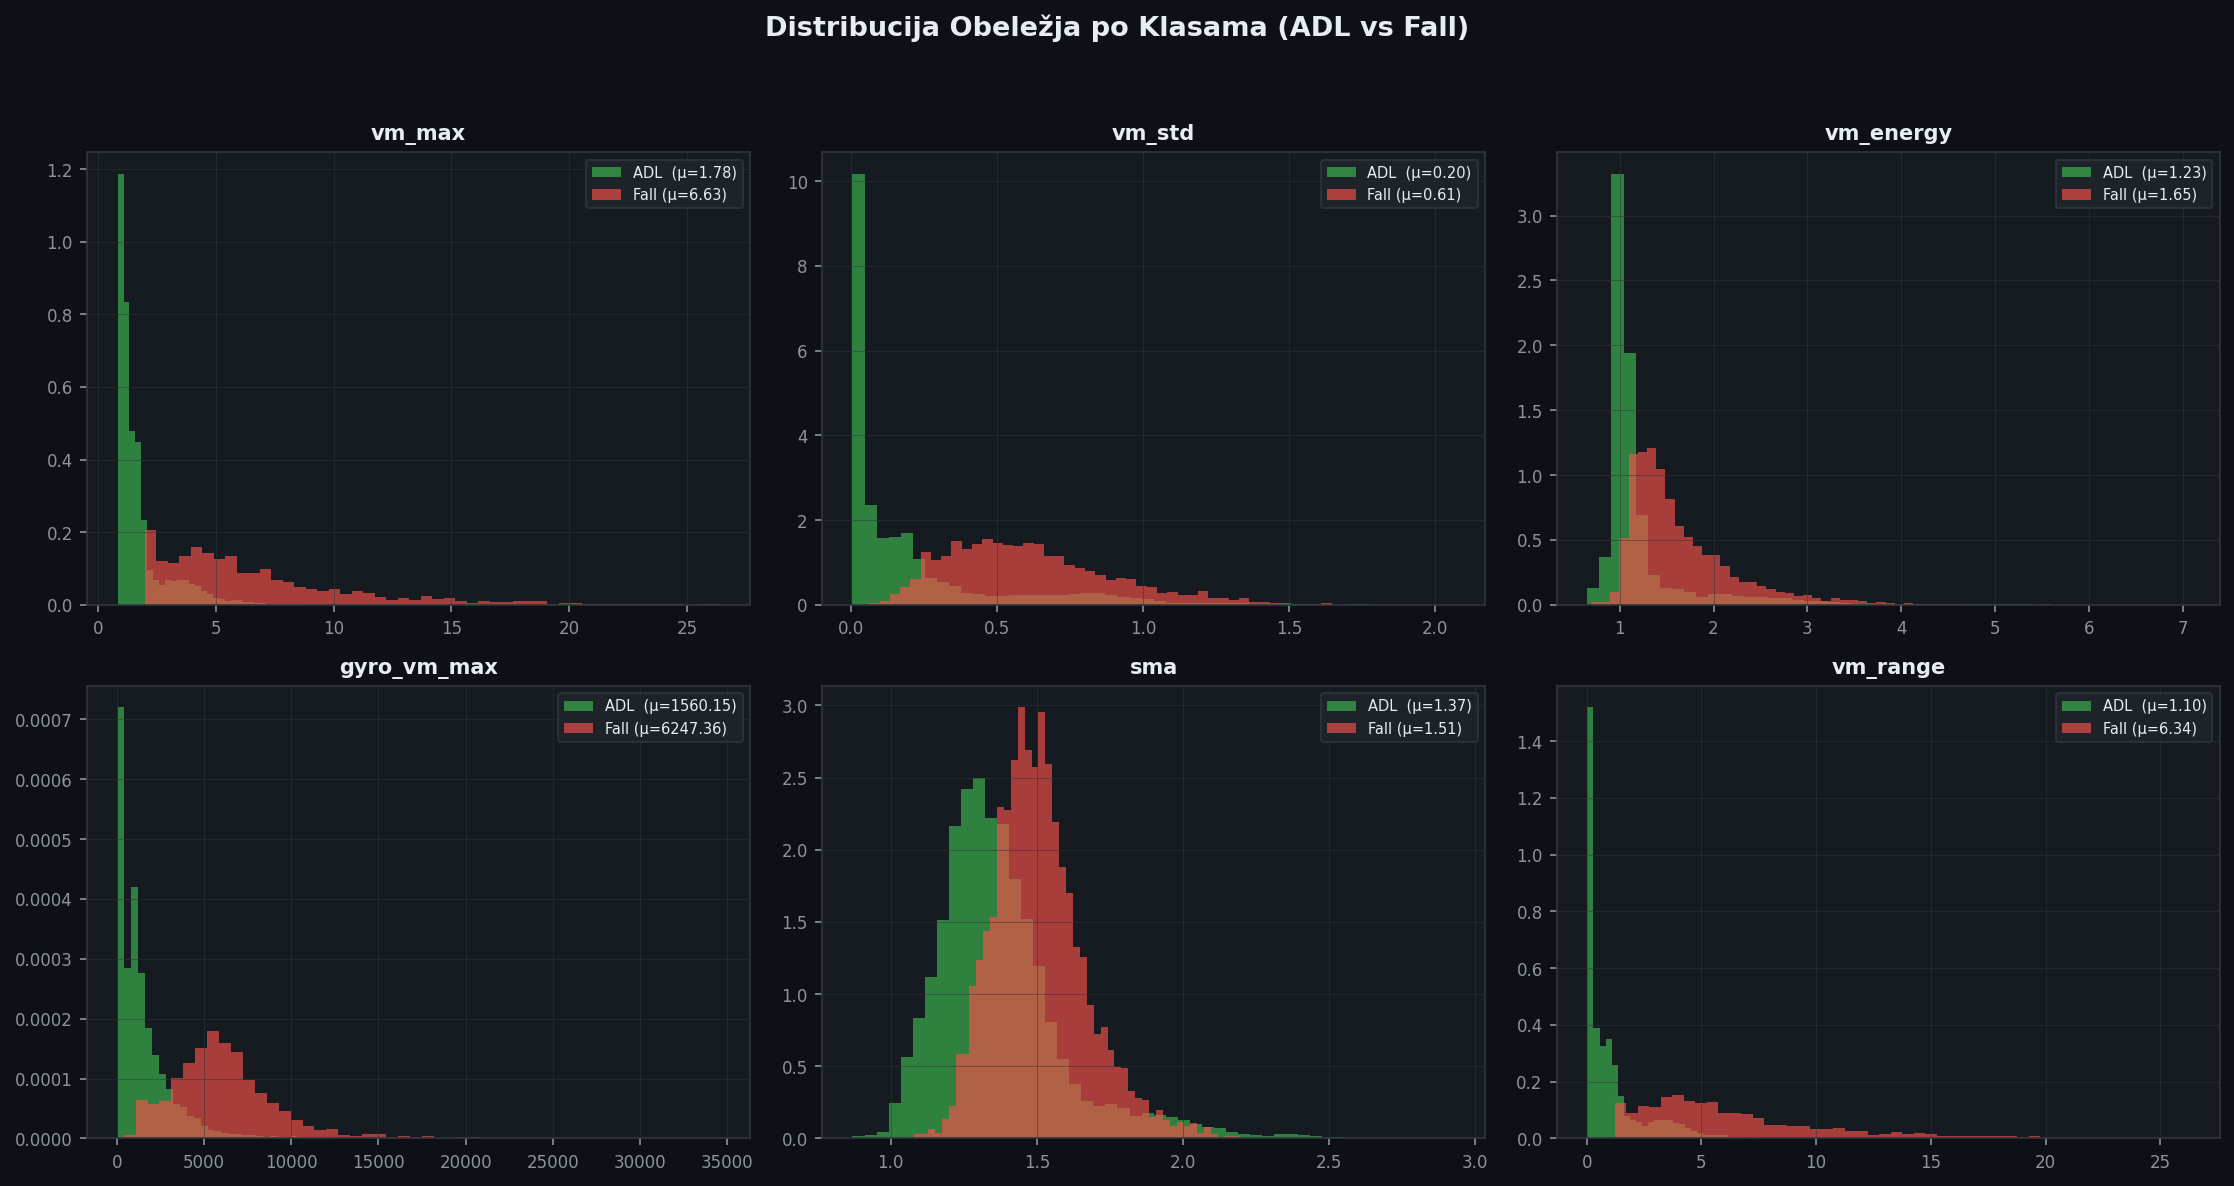

In [7]:
from IPython.display import Image, display

plot_feature_distributions(X, y, OUTPUT_DIR)
display(Image(os.path.join(OUTPUT_DIR, '2_feature_distributions.png'), width=900))


> **Interpretacija distribucija:**  
> - `vm_max`: Fall prozori imaju jasno desno-pomerenu distribuciju (visoke vrednosti = udarac). Ovo je **najdiskriminativniji** feature.  
> - `vm_std` i `vm_energy`: slična separabilnost — Fall prozori su haotičniji.  
> - `gyro_vm_max`: nagla promena ugla tela karakteristična za pad.  
> - `sma`: integrisana aktivnost po svim osama — dodatan signal za ADL vs Fall.  
> - `vm_range`: amplituda oscilacije — padovi imaju dramatičniji raspon.  
> 
> Histogrami sa dobrim razdvajanjem između klasa ukazuju da su ova obeležja pogodna za klasifikaciju čak i linearnim modelima.


---
## 4. Podela podataka — GroupKFold po subjektima

### Zašto GroupKFold umesto random split?
Svaki subjekt ima karakteristične obrasce kretanja (hod, tempo, telesna težina). Ako isti subjekt ima prozore i u train i u test setu, model "upamti" individualnog subjekta umesto da uči opšte karakteristike pada.

**Data Leakage:** Random `train_test_split` sa ovakvim podacima daje realistično visoke metrike u laboratoriji, ali loše performanse na novim osobama u praksi.

**GroupKFold rešenje:** Prozori istog subjekta su uvek u istom (train ili test) skupu. Test skup simulira *novu osobu* — realistična evaluacija.


In [5]:
print("=" * 60)
print("  PODELA PODATAKA — GroupKFold po subjektima")
print("=" * 60)

X_train, X_test, y_train, y_test, groups_train, scaler, split_info = \
    split_by_subjects(X, y, groups, test_subjects=None, n_splits=5)


  PODELA PODATAKA — GroupKFold po subjektima

  Podela podataka: GroupKFold (fold 5/5), test subjecti: [np.str_('SA04'), np.str_('SA07'), np.str_('SA09'), np.str_('SA12'), np.str_('SE01'), np.str_('SE05'), np.str_('SE09'), np.str_('SE15')]
  Train: 38326 prozora  (ADL=34692, Fall=3634)
  Test:  9357 prozora  (ADL=8656, Fall=701)
  Test subjecti: [np.str_('SA04'), np.str_('SA07'), np.str_('SA09'), np.str_('SA12'), np.str_('SE01'), np.str_('SE05'), np.str_('SE09'), np.str_('SE15')]
  Scaler: StandardScaler (fit samo na train setu)


> **Interpretacija:** Test subjekti su potpuno izolovani tokom treninga. Sve metrike koje vidimo u daljem tekstu su metrike *generalizacije na neviđene osobe*, što je relevantnija evaluacija za realni sistem.


---
## 5. Treniranje modela

Treniramo tri modela sa rastućom kompleksnošću. Svaki je odabran da pokrije različit ugao problema:

| Model | Tip | Prednost |
|---|---|---|
| **Gaussian NB** | Verovatnosni | Najbrži, baseline, interpretabilan |
| **kNN** | Metrički | Bez pretpostavki o raspodeli, grid search za k |
| **MLP** | Neuronska mreža | Nelinearna granica, dublja reprezentacija |

**Primarna metrika: Recall (Sensitivity)** — proporacija stvarnih padova koje sistem detektuje.  
Formula: Recall = TP / (TP + FN)  
Propušteni pravi pad (FN) je klinički opasan, dok je lažna uzbuna (FP) samo neugodnost.


In [14]:
print("=" * 60)
print("  TRENIRANJE MODELA")
print("=" * 60)

gnb_result = train_gnb(X_train, y_train, X_test, y_test)
knn_result = train_knn(X_train, y_train, X_test, y_test)
mlp_result = train_mlp(X_train, y_train, X_test, y_test,
                       epochs=100, batch_size=32, mlp_threshold=0.3)

results_list = [gnb_result, knn_result, mlp_result]
print("\n  ✓ Sva 3 modela su istrenirana.")


  TRENIRANJE MODELA

  [1/3] Gaussian Naive Bayes
        Pretpostavka: p(x_i | klasa) ~ Gaussian, obeležja nezavisna
        ✓ Trening: 0.0207s  |  Recall=0.8902  F1=0.5241

  [2/3] k-Nearest Neighbors
        Grid search za k ∈ [3, 5, 7, 9, 11, 15]  (kriterijum: max Recall, tiebreaker: F1)
          k= 3: Recall=0.8830  F1=0.8485
          k= 5: Recall=0.8830  F1=0.8805
          k= 7: Recall=0.8830  F1=0.8991
          k= 9: Recall=0.8845  F1=0.9104
          k=11: Recall=0.8830  F1=0.9150
          k=15: Recall=0.8759  F1=0.9144
        ✓ Optimalno: k=9  (Recall=0.8845)
        ✓ Trening: 0.0052s  |  Recall=0.8845  F1=0.9104

  [3/3] MLP Neuronska Mreža
        Arhitektura: 17→128(BN,D0.3)→64(BN,D0.2)→32→1(σ)
        Threshold: 0.3  |  Epochs: 100  |  Batch: 32
        Class weights: ADL=0.55, Fall=5.27
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6

> **Napomena o kNN Grid Search-u:**  
> Pretražuju se vrednosti `k ∈ {3, 5, 7, 9, 11, 15}` sa `weights='distance'` (bliži susedi imaju proporcionalno veći uticaj). Kriterijum odabira: max Recall, tiebreaker F1.
>
> **Napomena o MLP thresholdu (0.3):**  
> Standardni prag je 0.5 — predikcija = 1 ako model kaže p(Fall) ≥ 50%. Snižavanjem na 0.3, svaki prozor za koji model proceni makar 30% verovatnoću pada biće prijavljen. Ovo povećava Recall ali smanjuje Precision (više lažnih uzbuna). Prihvatljiv kompromis u medicinskom kontekstu.


---
## 6. Evaluacija i vizuelizacija rezultata

### Metrike
- **Accuracy** — % ispravnih predikcija (misleading kod imbalanced dataseta!)
- **Recall (Sensitivity)** — % stvarnih padova koje sistem detektuje ← *primarna metrika*
- **Precision** — % prijavljenih padova koji su zaista padovi
- **F1-Score** — harmonijska sredina Recall i Precision
- **Inference time** — ms po jednom prozoru (kritično za real-time Android app)

### Confusion matrice
Prikazuju normalizovane vrednosti po redovima (% unutar svake stvarne klase):
- TN (0→0): ADL tačno prepoznat
- FP (0→1): ADL pogrešno prijavljen kao pad (lažna uzbuna)
- FN (1→0): Pravi pad propušten ← **najopasnije**
- TP (1→1): Pravi pad tačno detektovan ← **cilj**


  VIZUELIZACIJA REZULTATA
  ✓ Evaluation grafik sačuvan: ./results\3_model_evaluation.png


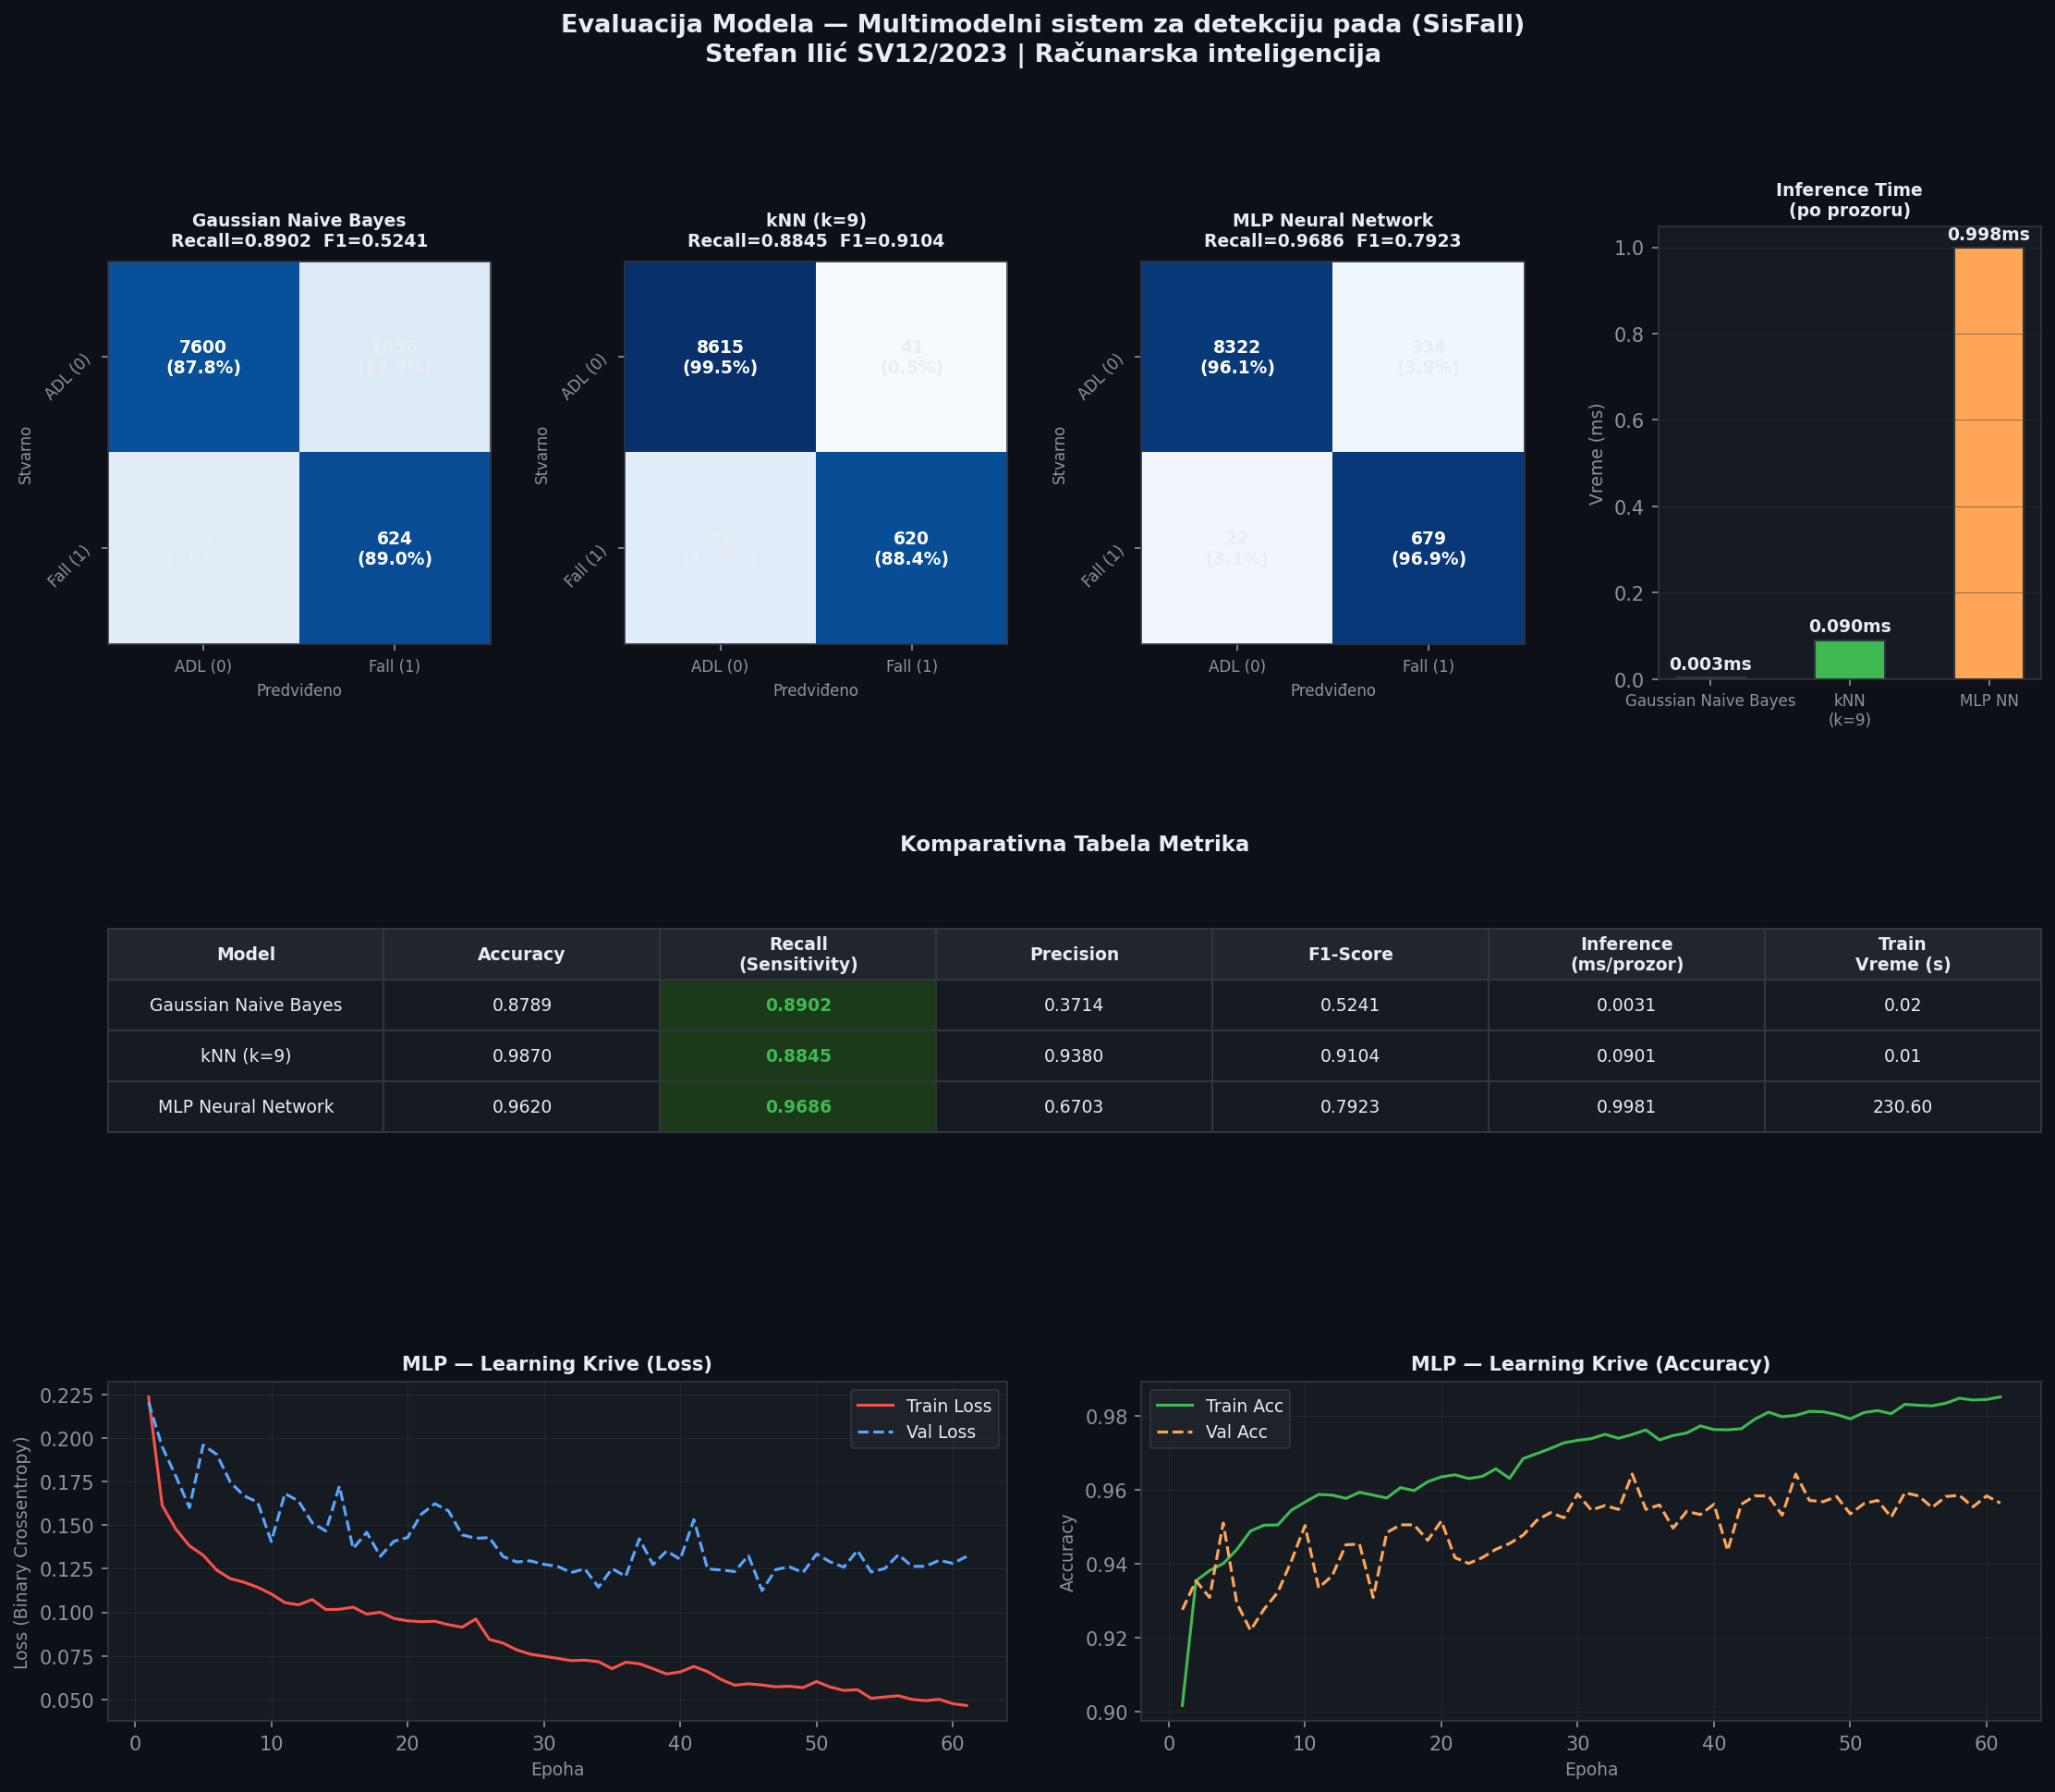

In [15]:
from IPython.display import Image, display

print("=" * 60)
print("  VIZUELIZACIJA REZULTATA")
print("=" * 60)

plot_model_results(results_list, OUTPUT_DIR)
display(Image(os.path.join(OUTPUT_DIR, '3_model_evaluation.png'), width=1000))


> **Interpretacija tabele:**  
> - Recall ≥ 0.85 je obojen **zeleno** — prihvatljiv prag za medicinski sistem  
> - Recall < 0.70 je obojen **crveno** — neprihvatljivo (premnogo propuštenih padova)  
> - Inference time: sva 3 modela treba da budu < 50ms za real-time upotrebu na mobilnom uređaju  
>  
> **Zašto MLP ima duže inference vreme?**  
> Forward pass kroz 3 skrivena sloja sa 128+64+32 neurona zahteva više float operacija od probabilističkih izračunavanja GNB-a ili pretraživanja stabla kNN-a.


  ✓ ROC krive sačuvane: ./results\4_roc_curves.png


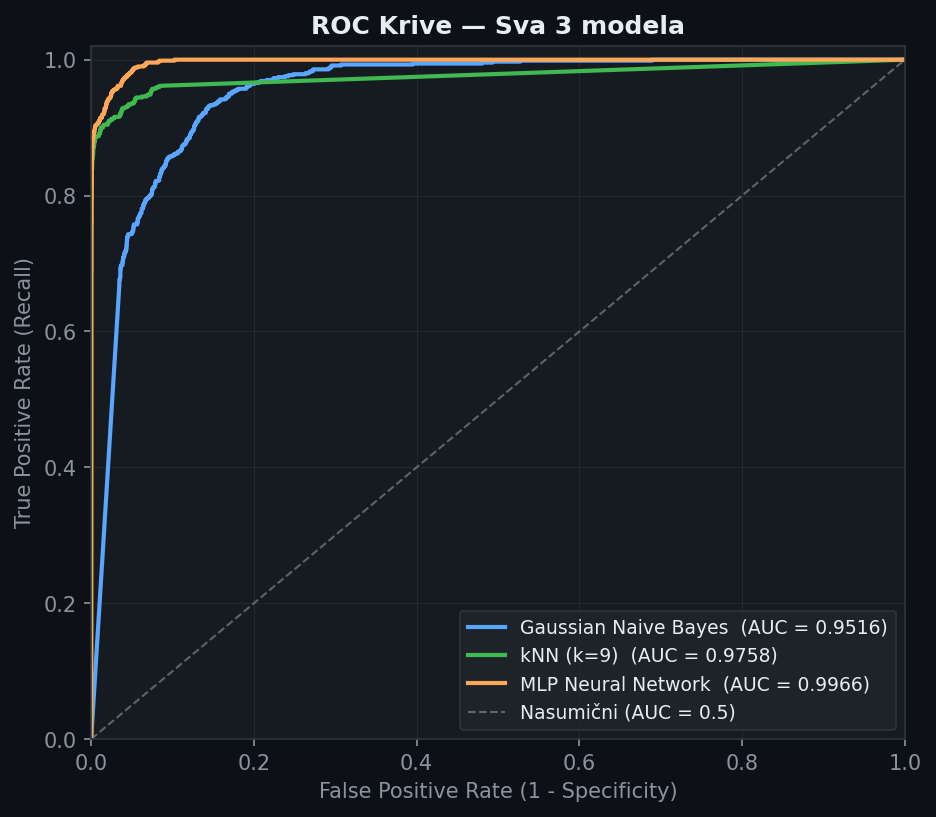

In [16]:
plot_roc_curves(results_list, y_test, OUTPUT_DIR)
display(Image(os.path.join(OUTPUT_DIR, '4_roc_curves.png'), width=560))


> **ROC krive — interpretacija:**  
> ROC kriva prikazuje odnos između True Positive Rate (Recall) i False Positive Rate za sve moguće pragove odluke. Model koji savršeno razdvaja klase ima AUC = 1.0 (gornji levi ugao). Dijagonala predstavlja nasumično pogađanje (AUC = 0.5).  
>  
> Poređenje AUC vrednosti između modela daje sliku robustnosti nezavisno od odabranog threshold-a.


---
## 7. Finalni zaključak


In [17]:
print_final_report(results_list, split_info=split_info, output_dir=OUTPUT_DIR)



  FINALNI IZVEŠTAJ

  Podela podataka: GroupKFold (fold 5/5), test subjecti: [np.str_('SA04'), np.str_('SA07'), np.str_('SA09'), np.str_('SA12'), np.str_('SE01'), np.str_('SE05'), np.str_('SE09'), np.str_('SE15')]
  Test subjecti:   [np.str_('SA04'), np.str_('SA07'), np.str_('SA09'), np.str_('SA12'), np.str_('SE01'), np.str_('SE05'), np.str_('SE09'), np.str_('SE15')]

  Model                          Acc   Recall       F1   Inf(ms)
  ────────────────────────────────────────────────────────────
  MLP Neural Network          0.9620   0.9686   0.7923    0.9981  ← BEST
  Gaussian Naive Bayes        0.8789   0.8902   0.5241    0.0031
  kNN (k=9)                   0.9870   0.8845   0.9104    0.0901
  ────────────────────────────────────────────────────────────

  Preporučeni model: MLP Neural Network
     Recall      = 0.9686   (% stvarnih padova detektovano)
     Precision   = 0.6703   (% lažnih uzbuna)
     F1-Score    = 0.7923
     Threshold   = 0.3
     Inference   = 0.9981 ms/prozor  (

In [18]:
import joblib
import os

MODELS_DIR = '..\\..\\backend\\models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Čuvanje sklearn modela
joblib.dump(gnb_result['model'], os.path.join(MODELS_DIR, 'gnb.pkl'))
joblib.dump(knn_result['model'], os.path.join(MODELS_DIR, 'knn.pkl'))
joblib.dump(scaler,              os.path.join(MODELS_DIR, 'scaler.pkl'))

# Čuvanje MLP-a
mlp_result['keras_model'].save(os.path.join(MODELS_DIR, 'mlp.keras'))

# Čuvanje naziva obeležja (backend koristi za validaciju)
import json
with open(os.path.join(MODELS_DIR, 'feature_names.json'), 'w') as f:
    json.dump(list(X.columns), f)

print("✓ Sačuvano:")
for fname in os.listdir(MODELS_DIR):
    size = os.path.getsize(os.path.join(MODELS_DIR, fname)) / 1024
    print(f"  {fname:<30} ({size:.1f} KB)")

✓ Sačuvano:
  feature_names.json             (0.2 KB)
  gnb.pkl                        (1.3 KB)
  knn.pkl                        (5390.4 KB)
  mlp.keras                      (200.5 KB)
  scaler.pkl                     (1.0 KB)
